Block size 4096: Data restored correctly.
Block size 4596: Data restoration failed.
Block size 5096: Data restoration failed.
Block size 5596: Data restoration failed.
Block size 6096: Data restoration failed.
Block size 6596: Data restoration failed.
Block size 7096: Data restoration failed.
Block size 7596: Data restoration failed.
Block size 8096: Data restoration failed.
Block size 8596: Data restoration failed.
Block size 9096: Data restoration failed.
Block size 9596: Data restoration failed.


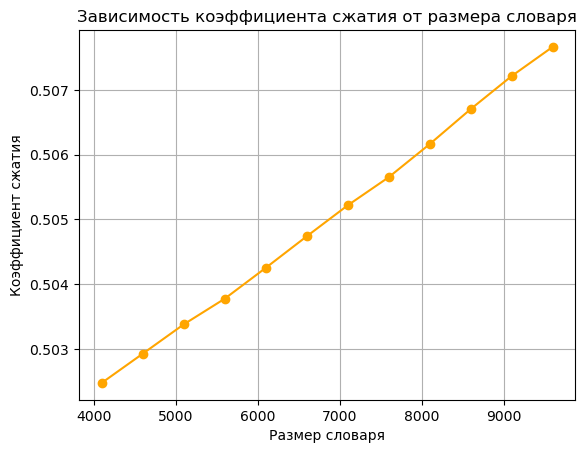

In [12]:
import matplotlib.pyplot as plt
def lzw_encode(data: bytes, max_dict_size: int = 4096):
    if not data:
        return b''
    
    encoded = bytearray()
    n = len(data)
    pos = 0
    
    # Инициализируем словарь всеми возможными байтами
    dictionary = {bytes([i]): i for i in range(256)}
    next_index = 256
    
    current_phrase = b""
    
    while pos < n:
        # Добавляем следующий байт
        current_byte = bytes([data[pos]])
        new_phrase = current_phrase + current_byte
        
        if new_phrase in dictionary:
            if next_index < max_dict_size:
                # Фраза есть в словаре, продолжаем
                current_phrase = new_phrase
                pos += 1
            else:
                # Словарь полон, но фраза существует.
                # Выдаем код для текущей фразы и начинаем новую с текущего байта.
                if current_phrase:  # Защита от пустой строки
                    prefix_index = dictionary[current_phrase]
                    encoded.extend(prefix_index.to_bytes(2, 'big'))
                current_phrase = current_byte
                pos += 1
        else:
            # Выдаем индекс текущей фразы
            prefix_index = dictionary[current_phrase]
            encoded.extend(prefix_index.to_bytes(2, 'big'))
            
            # Добавляем новую фразу в словарь (если не превышен лимит)
            if new_phrase and next_index < max_dict_size:
                dictionary[new_phrase] = next_index
                next_index += 1
            
            # Сбрасываем текущую фразу
            current_phrase = current_byte
            pos += 1
    
    # Обработка остатка
    if current_phrase:
        prefix_index = dictionary[current_phrase]
        encoded.extend(prefix_index.to_bytes(2, 'big'))
    
    return bytes(encoded)


def lzw_decode(encoded: bytes, max_dict_size: int = 4096):
    if not encoded:
        return b''
    
    decoded = bytearray()
    n = len(encoded)
    i = 0
    
    # Инициализируем словарь всеми возможными байтами
    dictionary = {i: bytes([i]) for i in range(256)}
    next_index = 256
    
    # Читаем первый индекс
    if i + 2 > n:
        return b''
    
    prev_index = int.from_bytes(encoded[i:i+2], 'big')
    i += 2
    
    # Первая фраза
    prev_phrase = dictionary.get(prev_index, b"")
    decoded.extend(prev_phrase)
    
    while i + 2 <= n:
        # Читаем следующий индекс
        curr_index = int.from_bytes(encoded[i:i+2], 'big')
        i += 2
        
        # Получаем фразу
        if curr_index in dictionary:
            curr_phrase = dictionary[curr_index]
        elif curr_index == next_index and next_index < max_dict_size:
            # Специальный случай: фраза, которую только будем добавлять
            curr_phrase = prev_phrase + bytes([prev_phrase[0]])
        else:
            # Некорректный индекс
            break
        
        # Добавляем в декодированный вывод
        decoded.extend(curr_phrase)
        
        # Добавляем новую фразу в словарь
        if next_index < max_dict_size and prev_phrase:
            new_phrase = prev_phrase + bytes([curr_phrase[0]])
            dictionary[next_index] = new_phrase
            next_index += 1
        
        prev_phrase = curr_phrase
    
    return bytes(decoded)

file_path = "C:/Users/irbis/Desktop/аисд 2 курс 2 сем/лаба 1/test_files/test4.raw"
dict_sizes = [x for x in range(4096,10000, 500)]
coeffs = []

with open(file_path, 'rb') as f:
        data = f.read()

for dict in dict_sizes:
    encoded = lzw_encode(data, dict)
    coeff = len(data) / len(encoded)
    coeffs.append(coeff)

    decoded = lzw_decode(encoded)

    if decoded == data:
        print(f"Block size {dict}: Data restored correctly.")
    else:
        print(f"Block size {dict}: Data restoration failed.")

plt.plot(dict_sizes, coeffs, marker='o',color = 'orange')
plt.xlabel('Размер словаря')
plt.ylabel('Коэффициент сжатия')
plt.title('Зависимость коэффициента сжатия от размера словаря')
plt.grid(True)
plt.show()